# Experimentation and uplift modeling

## Project objective

The goal of this project is to evaluate the impact of a marketing campaign on user conversion and assess whether treatment allocation can be improved through uplift modeling.

## Business context

In marketing and product analytics, companies frequently run controlled experiments to evaluate the impact of interventions such as email campaigns, promotions, or interface changes.

However, traditional A/B testing estimates only the average treatment effect and does not account for heterogeneous user responses. This may lead to suboptimal decisions, as some users would convert regardless of treatment, while others may respond negatively.

More advanced approaches allow both:
- increasing statistical efficiency (via variance reduction),
- and improving business outcomes through targeted interventions.

## Modeling task

The analysis begins with a classical A/B test to estimate the incremental effect of treatment on conversion at the population level.

It then extends to uplift modeling, where the objective is to rank users by their expected incremental response to treatment and identify segments with the highest business value.

In addition, the project includes a CUPED-based variance reduction step to examine whether pre-treatment information can improve the precision of treatment effect estimation for noisy outcomes such as spend.


## Evaluation criterion

For the A/B testing part, the primary outcome metric is conversion rate, since conversion is the main business outcome of the campaign. The result is interpreted through its statistical significance.

For the uplift modeling part, the primary model selection metric is the Qini coefficient, since it measures how well the model ranks users by expected incremental treatment effect relative to random targeting.

CUPED is evaluated separately as a supporting efficiency technique, with the focus on whether it meaningfully reduces variance.

## Table of contents

- [Imports and notebook setup](#imports-and-notebook-setup)
- [Data loading and initial quality checks](#data-loading-and-initial-quality-checks)
- [Initial descriptive analysis](#initial-descriptive-analysis)
- [Binary A/B experiment setup](#binary-ab-experiment-setup)
- [Pre-treatment balance check](#pre-treatment-balance-check)
- [Baseline A/B test for conversion](#baseline-ab-test-for-conversion)
- [Post hoc power and detectable effect diagnostics](#post-hoc-power-and-detectable-effect-diagnostics)
- [Spend distribution and variance diagnostics](#spend-distribution-and-variance-diagnostics)
- [CUPED adjustment for spend](#cuped-adjustment-for-spend)
- [Uplift modeling](#uplift-modeling)
- [Final conclusions](#final-conclusions)

<a id="imports-and-notebook-setup"></a>
## Imports and notebook setup

In [1]:
import warnings
import shutil
import subprocess
import zipfile
from math import sqrt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

warnings.filterwarnings("ignore")

In [2]:
# Notebook display helpers
from IPython.display import display, Markdown, HTML
import io

def md(text: str):
    display(Markdown(text))

def show_kv(title: str, value):
    md(f"**{title}:** `{value}`")

def show_df(title: str, df, head: int = 5):
    md(f"**{title}**")
    display(df.head(head))

def df_info(df):
    buf = io.StringIO()
    df.info(buf = buf)
    md("```text\n" + buf.getvalue() + "\n```")

def show_missing(df, title: str):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending = False)
    md(f"**{title}**")
    display(miss.to_frame("missing_count"))

def show_table(title: str, df: pd.DataFrame, round_n: int | None = None, sort_by: str | None = None, ascending: bool = True):
    md(f"**{title}**")
    out = df.copy()
    if sort_by is not None and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending = ascending)
    if round_n is not None:
        out = out.round(round_n)
    display(out)

def show_metrics(title: str, metrics: dict, round_n: int = 5):
    md(f"**{title}**")
    df = pd.DataFrame({"Metric": list(metrics.keys()), "Value": list(metrics.values())})
    df["Value"] = df["Value"].apply(lambda x: round(x, round_n) if isinstance(x, (int, float, np.floating, np.integer)) else x)
    display(df)

def show_search_results(model_name: str, search_cv):
    md(f"**Hyperparameter search:** `{model_name}`")

    best_params = search_cv.best_params_
    best_score = search_cv.best_score_

    best_rmsle = -best_score if best_score is not None else np.nan
    show_kv("Best RMSLE (CV)", round(float(best_rmsle), 5))

    md("**Best parameters**")
    display(pd.DataFrame({
        "param": list(best_params.keys()),
        "value": list(best_params.values())}))

<a id="data-loading-and-initial-quality-checks"></a>
## Data loading and initial quality checks

In [3]:
DATA_DIR = Path("../data/hillstrom_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = "bofulee/kevin-hillstrom-minethatdata-e-mailanalytics"


def find_csv_files(data_dir: Path) -> list[Path]:
    return list(data_dir.rglob("*.csv"))


def load_hillstrom_data(data_dir: Path, dataset_id: str) -> Path:
    # If CSV already exists, do not download again
    csv_files = find_csv_files(data_dir)
    if csv_files:
        return csv_files[0]

    # Check Kaggle CLI
    if shutil.which("kaggle") is None:
        raise RuntimeError(
            "Kaggle CLI is not found. Install it with: pip install kaggle"
        )

    # Check Kaggle token
    kaggle_token_path = Path.home() / ".kaggle" / "kaggle.json"
    if not kaggle_token_path.exists():
        raise RuntimeError(
            "Kaggle API token is not found at ~/.kaggle/kaggle.json"
        )

    # Download zip
    result = subprocess.run(
        [
            "kaggle", "datasets", "download",
            "-d", dataset_id,
            "-p", str(data_dir),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"Kaggle download failed.\nSTDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}"
        )

    # Find downloaded zip
    zip_files = list(data_dir.glob("*.zip"))
    if not zip_files:
        raise RuntimeError(
            "Dataset download finished, but no ZIP archive was found in the target folder."
        )

    # If several zips somehow exist, take the latest modified one
    zip_path = max(zip_files, key=lambda p: p.stat().st_mtime)

    # Extract zip
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(data_dir)

    # Optional: delete zip after extraction
    zip_path.unlink()

    # Check that CSV appeared
    csv_files = find_csv_files(data_dir)
    if not csv_files:
        raise RuntimeError(
            "Archive was extracted, but no CSV file was found afterwards."
        )

    return csv_files[0]


csv_path = load_hillstrom_data(DATA_DIR, DATASET_ID)
df = pd.read_csv(csv_path)

# Basic inspection
show_kv("Data shape", df.shape)

show_df("Data preview", df, head = 5)

md("**Data structure and types**")
df_info(df)

show_missing(df, "Data missing values")

**Data shape:** `(64000, 12)`

**Data preview**

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


**Data structure and types**

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB

```

**Data missing values**

,missing_count


- The dataset contains 64,000 user-level observations with no missing values, indicating high data quality and suitability for further analysis.

<a id="initial-descriptive-analysis"></a>
## Initial descriptive analysis

In [4]:
segment_stats = (
    df.groupby("segment")
    .agg(
        users=("segment", "size"),
        share=("segment", lambda x: len(x) / len(df)),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
        avg_spend=("spend", "mean"),
        avg_recency=("recency", "mean"),
        avg_history=("history", "mean")
    )
    .reset_index()
)

show_table(
    "Segment-level statistics",
    segment_stats,
    round_n=4,
    sort_by="share",
    ascending=False
)

show_metrics(
    "Overall spend statistics",
    {
        "Mean spend": df["spend"].mean(),
        "Std spend": df["spend"].std(),
        "Median spend": df["spend"].median(),
        "99th percentile spend": df["spend"].quantile(0.99),
        "Max spend": df["spend"].max(),
        "Share of zero spend": (df["spend"] == 0).mean(),
    },
    round_n=4
)

**Segment-level statistics**

,segment,users,share,visit_rate,conversion_rate,avg_spend,avg_recency,avg_history
2,Womens E-Mail,21387,0.3342,0.1514,0.0088,1.0772,5.7678,242.5366
0,Mens E-Mail,21307,0.3329,0.1828,0.0125,1.4226,5.7736,242.8359
1,No E-Mail,21306,0.3329,0.1062,0.0057,0.6528,5.7497,240.8827


**Overall spend statistics**

,Metric,Value
0,Mean spend,1.0509
1,Std spend,15.0364
2,Median spend,0.0000
3,99th percentile spend,0.0000
4,Max spend,499.0000
5,Share of zero spend,0.9910


- The dataset contains three experimental groups: `Womens E-Mail`, `Mens E-Mail`, and `No E-Mail`.
- At the aggregate level, both email campaigns show higher visit and conversion rates than the control group, and the `Mens E-Mail` campaign has the highest conversion rate among the three groups.
- The spend distribution is highly skewed: most users do not purchase at all, while a small number of users generate large spend values. This is important for later variance analysis.

<a id="binary-ab-experiment-setup"></a>
## Binary A/B experiment setup

In [5]:
md("**Problem setup**")

# Restrict to binary experiment: control vs Mens E-Mail
df_ab = df[df["segment"].isin(["No E-Mail", "Mens E-Mail"])].copy()

# Create binary treatment indicator
df_ab["treatment"] = (df_ab["segment"] == "Mens E-Mail").astype(int)

# Define target
TARGET = "conversion"

# Define pre-treatment features
FEATURES = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
    "channel",
    "zip_code"
]

show_kv("Filtered dataset shape", df_ab.shape)

show_df("Filtered data preview", df_ab, head = 5)

show_table(
    "Treatment distribution",
    df_ab["treatment"].value_counts(normalize=True).rename("share").to_frame(),
    round_n=6
)

**Problem setup**

**Filtered dataset shape:** `(42613, 13)`

**Filtered data preview**

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0,1
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,Mens E-Mail,1,0,0.0,1
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,No E-Mail,0,0,0.0,0


**Treatment distribution**

,share
treatment,
1,0.500012
0,0.499988


- The analysis is restricted to a binary comparison between users who received `No E-Mail` (control) and users exposed to the `Mens E-Mail` campaign (treatment).
- The outcome of interest is `conversion`.
- Only pre-treatment user characteristics are used as covariates, while post-treatment variables are excluded to ensure a valid causal setup.
- Overall, the data is transformed into a clean binary experiment with clearly defined treatment, outcome, and covariates, providing a consistent basis for A/B testing, variance reduction, and uplift modeling.

<a id="pre-treatment-balance-check"></a>
## Pre-treatment balance check

In [6]:
md("**Balance check before outcome analysis**")

def smd(x_t, x_c):
    var_t = np.var(x_t, ddof=1)
    var_c = np.var(x_c, ddof=1)
    pooled_sd = np.sqrt((var_t + var_c) / 2)
    if pooled_sd == 0:
        return 0.0
    return (np.mean(x_t) - np.mean(x_c)) / pooled_sd

control_mask = df_ab["treatment"] == 0
treat_mask = df_ab["treatment"] == 1

balance_rows = []
for col in ["recency", "history", "mens", "womens", "newbie"]:
    x_c = df_ab.loc[control_mask, col]
    x_t = df_ab.loc[treat_mask, col]

    balance_rows.append({
        "feature": col,
        "control_mean": x_c.mean(),
        "treatment_mean": x_t.mean(),
        "absolute_difference": x_t.mean() - x_c.mean(),
        "SMD": smd(x_t, x_c),
    })

balance_df = pd.DataFrame(balance_rows)

show_table(
    "Balance check for numeric/binary pre-treatment features",
    balance_df,
    round_n=4
)

channel_dist = (
    pd.crosstab(df_ab["channel"], df_ab["treatment"], normalize="columns")
    .rename(columns={0: "control_share", 1: "treatment_share"})
    .reset_index()
)

zip_dist = (
    pd.crosstab(df_ab["zip_code"], df_ab["treatment"], normalize="columns")
    .rename(columns={0: "control_share", 1: "treatment_share"})
    .reset_index()
)

show_table("Channel distribution by group", channel_dist, round_n=4)
show_table("Zip code distribution by group", zip_dist, round_n=4)

**Balance check before outcome analysis**

**Balance check for numeric/binary pre-treatment features**

,feature,control_mean,treatment_mean,absolute_difference,SMD
0,recency,5.7497,5.7736,0.0239,0.0068
1,history,240.8827,242.8359,1.9533,0.0076
2,mens,0.5532,0.5509,-0.0023,-0.0046
3,womens,0.5476,0.5514,0.0038,0.0076
4,newbie,0.5020,0.5015,-0.0004,-0.0009


**Channel distribution by group**

treatment,channel,control_share,treatment_share
0,Multichannel,0.1223,0.1209
1,Phone,0.4378,0.4337
2,Web,0.4399,0.4454


**Zip code distribution by group**

treatment,zip_code,control_share,treatment_share
0,Rural,0.1473,0.1522
1,Surburban,0.4518,0.4459
2,Urban,0.4009,0.4019


- The treatment and control groups are almost equal in size.
- For the observed *pre-treatment* characteristics, the group means and category shares are very similar. This supports the view that the two groups are reasonably balanced on observed covariates.
- This does not prove perfect randomization, but it is sufficient to proceed with the A/B analysis without obvious signs of pre-treatment imbalance.

<a id="baseline-ab-test-for-conversion"></a>
## Baseline A/B test for conversion

In [7]:
md("**Baseline A/B test: conversion**")

md("""
The analysis is based on a two-sided z-test for the difference in proportions.
- **Null hypothesis (H0):** the conversion rate is equal in the treatment and control groups.
- **Alternative hypothesis (H1):** the conversion rate differs between the treatment and control groups.
""")

# Group-level summary
ab_summary = (
    df_ab.groupby("treatment")
    .agg(
        users=("conversion", "size"),
        conversions=("conversion", "sum"),
        conversion_rate=("conversion", "mean"),
    )
)

ab_summary.index = ab_summary.index.map({0: "Control", 1: "Treatment"})

show_table(
    "A/B conversion summary",
    ab_summary,
    round_n=4
)

# Extract group metrics
n_c = ab_summary.loc["Control", "users"]
n_t = ab_summary.loc["Treatment", "users"]

conv_c = ab_summary.loc["Control", "conversions"]
conv_t = ab_summary.loc["Treatment", "conversions"]

p_c = ab_summary.loc["Control", "conversion_rate"]
p_t = ab_summary.loc["Treatment", "conversion_rate"]

# Effect size
absolute_uplift = p_t - p_c
relative_uplift = absolute_uplift / p_c if p_c > 0 else np.nan

# Standard error for CI
se = sqrt(
    p_t * (1 - p_t) / n_t +
    p_c * (1 - p_c) / n_c
)

# 95% CI
z_crit = norm.ppf(0.975)
ci_low = absolute_uplift - z_crit * se
ci_high = absolute_uplift + z_crit * se

# Two-sided z-test with pooled proportion under H0
p_pool = (conv_t + conv_c) / (n_t + n_c)
se_null = sqrt(p_pool * (1 - p_pool) * (1 / n_t + 1 / n_c))
z_stat = absolute_uplift / se_null
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

# Practical interpretation
expected_treat_conversions_under_control_rate = p_c * n_t
incremental_conversions = conv_t - expected_treat_conversions_under_control_rate

show_metrics(
    "A/B test results",
    {
        "Control conversion rate": p_c,
        "Treatment conversion rate": p_t,
        "Absolute uplift": absolute_uplift,
        "Absolute uplift (percentage points)": absolute_uplift * 100,
        "Relative uplift": relative_uplift,
        "Standard error": se,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high,
        "95% CI lower (percentage points)": ci_low * 100,
        "95% CI upper (percentage points)": ci_high * 100,
        "Z-statistic": z_stat,
        "Two-sided p-value": f"{p_value:.3e}",
        "Observed treatment conversions": conv_t,
        "Expected treatment conversions under control rate": expected_treat_conversions_under_control_rate,
        "Incremental conversions in treatment group": incremental_conversions,
    },
    round_n=4
)

effect_summary = pd.DataFrame({
    "metric": [
        "Control conversion rate (%)",
        "Treatment conversion rate (%)",
        "Absolute uplift (p.p.)",
        "Relative uplift (%)",
        "Incremental conversions"
    ],
    "value": [
        p_c * 100,
        p_t * 100,
        absolute_uplift * 100,
        relative_uplift * 100,
        incremental_conversions
    ]
})

show_table("Effect size summary", effect_summary, round_n=4)

**Baseline A/B test: conversion**


The analysis is based on a two-sided z-test for the difference in proportions.
- **Null hypothesis (H0):** the conversion rate is equal in the treatment and control groups.
- **Alternative hypothesis (H1):** the conversion rate differs between the treatment and control groups.


**A/B conversion summary**

,users,conversions,conversion_rate
treatment,,,
Control,21306,122,0.0057
Treatment,21307,267,0.0125


**A/B test results**

,Metric,Value
0,Control conversion rate,0.0057
1,Treatment conversion rate,0.0125
2,Absolute uplift,0.0068
3,Absolute uplift (percentage points),0.6805
4,Relative uplift,1.1884
5,Standard error,0.0009
6,95% CI lower,0.005
7,95% CI upper,0.0086
8,95% CI lower (percentage points),0.5
9,95% CI upper (percentage points),0.861


**Effect size summary**

,metric,value
0,Control conversion rate (%),0.5726
1,Treatment conversion rate (%),1.2531
2,Absolute uplift (p.p.),0.6805
3,Relative uplift (%),118.8422
4,Incremental conversions,144.9943


- The conversion rate is `0.57%` in the control group and `1.25%` in the treatment group.
- The estimated treatment effect is `0.68 percentage points`, which corresponds to a `118.8%` relative increase over the control conversion rate.
- The 95% confidence interval for the absolute uplift is `[0.50; 0.86] percentage points`.
- The two-sided z-test gives `p-value < 0.0001`, so the null hypothesis of equal conversion rates is rejected.
- In practical terms, the treatment group generated about `145 incremental conversions` relative to what would be expected under the control conversion rate.
- Overall, the `Mens E-Mail` campaign shows a statistically significant and practically meaningful positive effect on conversion.

<a id="post-hoc-power-and-detectable-effect-diagnostics"></a>
## Post hoc power and detectable effect diagnostics

In [8]:
alpha = 0.05
target_power = 0.80
ratio = n_t / n_c

# Observed rates from the A/B test
p0 = p_c   # control conversion rate
p1 = p_t   # treatment conversion rate
observed_uplift = p1 - p0

power_analysis = NormalIndPower()

# Cohen's h for two proportions
effect_size = proportion_effectsize(p1, p0)

# Achieved (post hoc) power for the observed effect
achieved_power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=n_c,
    alpha=alpha,
    ratio=ratio,
    alternative="two-sided"
)

# Minimum detectable effect (MDE) for the current sample size (Cohen's h)
mde_effect_size = power_analysis.solve_power(
    power=target_power,
    nobs1=n_c,
    alpha=alpha,
    ratio=ratio,
    alternative="two-sided"
)

# Convert Cohen's h back to proportion uplift, using control rate as baseline
def uplift_from_effect_size(h, p_base):
    return np.sin((h + 2 * np.arcsin(np.sqrt(p_base))) / 2) ** 2 - p_base

mde = uplift_from_effect_size(mde_effect_size, p0)

# Required sample size per group to detect the observed uplift
required_n_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=target_power,
    alpha=alpha,
    ratio=1.0,
    alternative="two-sided"
)

posthoc_df = pd.DataFrame({
    "metric": [
        "Control conversion rate",
        "Treatment conversion rate",
        "Observed uplift",
        "Observed uplift (p.p.)",
        "Achieved power",
        "Target power",
        "Minimum detectable effect",
        "Minimum detectable effect (p.p.)",
        "Required sample size per group",
        "Actual control group size",
        "Actual treatment group size",
        "Actual / required sample size"
    ],
    "value": [
        p0,
        p1,
        observed_uplift,
        observed_uplift * 100,
        achieved_power,
        target_power,
        mde,
        mde * 100,
        required_n_per_group,
        n_c,
        n_t,
        min(n_c, n_t) / required_n_per_group
    ]
})

show_table(
    "Post hoc power and detectable effect summary",
    posthoc_df,
    round_n=6
)

**Post hoc power and detectable effect summary**

,metric,value
0,Control conversion rate,0.005726
1,Treatment conversion rate,0.012531
2,Observed uplift,0.006805
3,Observed uplift (p.p.),0.680501
4,Achieved power,1.000000
5,Target power,0.800000
6,Minimum detectable effect,0.002230
7,Minimum detectable effect (p.p.),0.222986
8,Required sample size per group,2956.369817
9,Actual control group size,21306.000000


- The experiment was sufficiently powered: the observed uplift in conversion is substantially larger than the minimum detectable effect.
- The actual sample size far exceeds the required level.
- The achieved power is close to 1.00, which is consistent with the large sample and the observed effect size.

<a id="spend-distribution-and-variance-diagnostics"></a>
## Spend distribution and variance diagnostics

In [9]:
md("**Variance analysis and CUPED**")

spend_summary = (
    df_ab.groupby("treatment")
    .agg(
        users=("spend", "size"),
        mean_spend=("spend", "mean"),
        median_spend=("spend", "median"),
        std_spend=("spend", "std"),
        zero_spend_share=("spend", lambda x: (x == 0).mean()),
        p99_spend=("spend", lambda x: x.quantile(0.99)),
        max_spend=("spend", "max"),
    )
)

spend_summary.index = spend_summary.index.map({0: "Control", 1: "Treatment"})

show_table(
    "Spend summary by group",
    spend_summary,
    round_n=4
)

variance_stats = {
    "Overall mean spend": df_ab["spend"].mean(),
    "Overall std spend": df_ab["spend"].std(),
    "Overall variance of spend": df_ab["spend"].var(),
    "Overall median spend": df_ab["spend"].median(),
    "Share of zero spend": (df_ab["spend"] == 0).mean(),
    "99th percentile of spend": df_ab["spend"].quantile(0.99),
    "Max spend": df_ab["spend"].max(),
    "Mean history": df_ab["history"].mean(),
    "Std history": df_ab["history"].std(),
    "Correlation: history vs spend": df_ab["history"].corr(df_ab["spend"]),
    "Correlation: history vs conversion": df_ab["history"].corr(df_ab["conversion"]),
}

show_metrics(
    "Variance diagnostics",
    variance_stats,
    round_n=4
)

**Variance analysis and CUPED**

**Spend summary by group**

,users,mean_spend,median_spend,std_spend,zero_spend_share,p99_spend,max_spend
treatment,,,,,,,
Control,21306,0.6528,0.0,11.5882,0.9943,0.00,499.0
Treatment,21307,1.4226,0.0,17.7542,0.9875,29.99,499.0


**Variance diagnostics**

,Metric,Value
0,Overall mean spend,1.0377
1,Overall std spend,14.9965
2,Overall variance of spend,224.8941
3,Overall median spend,0.0000
4,Share of zero spend,0.9909
5,99th percentile of spend,0.0000
6,Max spend,499.0000
7,Mean history,241.8593
8,Std history,256.5747
9,Correlation: history vs spend,0.0209


- The spend outcome is extremely sparse and noisy.
- Most users have zero post-campaign spend, the median is zero, and even the 99th percentile is still zero. This means that fewer than 1% of users generate any substantial revenue, while a very small number of observations drive the upper tail.
- As a result, treatment effect estimation for spend is inherently noisy and much less stable than treatment effect estimation for conversion.
- The pre-experiment variable `history` is a valid CUPED covariate because it is measured before treatment assignment. However, its correlation with post-treatment spend is extremely weak, which suggests that only minimal variance reduction should be expected.

<a id="cuped-adjustment-for-spend"></a>
## CUPED adjustment for spend

In [10]:
md("**CUPED adjustment for spend**")

# Define outcome and pre-experiment covariate
y = df_ab["spend"]
x = df_ab["history"]

# CUPED coefficient
theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)

# CUPED-adjusted outcome
df_ab["spend_cuped"] = y - theta * (x - x.mean())

# Overall comparison: raw vs CUPED-adjusted spend
cuped_comparison = pd.DataFrame(
    {
        "metric": ["spend", "spend_cuped"],
        "mean": [df_ab["spend"].mean(), df_ab["spend_cuped"].mean()],
        "std": [df_ab["spend"].std(), df_ab["spend_cuped"].std()],
        "variance": [df_ab["spend"].var(), df_ab["spend_cuped"].var()],
    }
)

show_table(
    "Raw vs CUPED-adjusted spend",
    cuped_comparison,
    round_n=4
)

# Variance reduction
corr_spend_history = df_ab["history"].corr(df_ab["spend"])
expected_variance_reduction = corr_spend_history ** 2
observed_variance_reduction = 1 - df_ab["spend_cuped"].var() / df_ab["spend"].var()

show_metrics(
    "CUPED diagnostics",
    {
        "CUPED theta": theta,
        "Correlation: history vs spend": corr_spend_history,
        "Expected variance reduction (~corr^2)": expected_variance_reduction,
        "Expected variance reduction (%)": expected_variance_reduction * 100,
        "Observed variance reduction": observed_variance_reduction,
        "Observed variance reduction (%)": observed_variance_reduction * 100,
    },
    round_n=6
)

**CUPED adjustment for spend**

**Raw vs CUPED-adjusted spend**

,metric,mean,std,variance
0,spend,1.0377,14.9965,224.8941
1,spend_cuped,1.0377,14.9932,224.7956


**CUPED diagnostics**

,Metric,Value
0,CUPED theta,0.001223
1,Correlation: history vs spend,0.020923
2,Expected variance reduction (~corr^2),0.000438
3,Expected variance reduction (%),0.043775
4,Observed variance reduction,0.000438
5,Observed variance reduction (%),0.043775


In [11]:
def diff_in_means_summary(df, outcome_col, treatment_col="treatment"):
    grp = df.groupby(treatment_col)[outcome_col]

    mean_c = grp.mean().loc[0]
    mean_t = grp.mean().loc[1]

    var_c = grp.var().loc[0]
    var_t = grp.var().loc[1]

    n_c = grp.size().loc[0]
    n_t = grp.size().loc[1]

    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)

    z_crit = norm.ppf(0.975)
    ci_low = diff - z_crit * se
    ci_high = diff + z_crit * se

    return {
        "control_mean": mean_c,
        "treatment_mean": mean_t,
        "treatment_effect": diff,
        "standard_error": se,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high,
    }

raw_spend_effect = diff_in_means_summary(df_ab, "spend")
cuped_spend_effect = diff_in_means_summary(df_ab, "spend_cuped")

spend_effect_comparison = pd.DataFrame([
    {"metric": "Raw spend", **raw_spend_effect},
    {"metric": "CUPED-adjusted spend", **cuped_spend_effect},
])

show_table(
    "Treatment effect on spend: raw vs CUPED-adjusted",
    spend_effect_comparison,
    round_n=6
)

**Treatment effect on spend: raw vs CUPED-adjusted**

,metric,control_mean,treatment_mean,treatment_effect,standard_error,95% CI lower,95% CI upper
0,Raw spend,0.652789,1.422617,0.769827,0.145247,0.485149,1.054505
1,CUPED-adjusted spend,0.653984,1.421422,0.767438,0.145215,0.482822,1.052055


- The estimated CUPED coefficient is `0.001223`, which is very small. The correlation between `history` and `spend` is also extremely weak (`0.0209`), so only minimal variance reduction is expected.
- The theoretical variance reduction based on `corr²` is `0.0438%`, and the observed variance reduction after CUPED adjustment is exactly `0.0438%`. This confirms that the CUPED implementation is correct, but the covariate is too weak to provide any meaningful practical benefit.
- Before adjustment, the estimated treatment effect on spend is `0.7698` with a 95% confidence interval of `[0.4851; 1.0545]`. After CUPED adjustment, the estimated effect is `0.7674` with a 95% confidence interval of `[0.4828; 1.0521]`.
- The standard error decreases only from `0.1452` to `0.1452`, which is negligible.
- Overall, CUPED is not practically useful in this setting because `history` has almost no explanatory power for post-treatment `spend`.

<a id="uplift-modeling"></a>
## Uplift modeling

- The A/B test shows a positive average treatment effect, but the average effect alone does not describe user-level heterogeneity.
- Uplift modeling is used to estimate how much the treatment changes conversion probability for each user individually. This makes it possible to move from a uniform policy (send the email to everyone) to a targeted policy (send the email only to users with the highest expected incremental impact).

In [12]:
# Feature groups
numeric_features = ["recency", "history", "mens", "womens", "newbie"]
categorical_features = ["channel", "zip_code"]

In [13]:
# Shared helpers

def clone_with_random_state(estimator, random_state):
    est = clone(estimator)
    params = est.get_params(deep=False)
    if "random_state" in params:
        est.set_params(random_state=random_state)
    return est


def make_uplift_split(
    df,
    features,
    target,
    treatment_col,
    test_size=0.3,
    random_state=42,
):
    X = df[features].copy()
    y = df[target].astype(int).copy()
    t = df[treatment_col].astype(int).copy()

    stratify_key = t.astype(str) + "_" + y.astype(str)

    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X,
        y,
        t,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_key
    )

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "t_train": t_train,
        "t_test": t_test,
    }


def build_preprocessor(
    numeric_features,
    categorical_features,
    scale_numeric_for_linear=True
):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]

    if scale_numeric_for_linear:
        num_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(num_steps),
                numeric_features,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop"
    )
    return preprocessor


def make_uplift_results(X_test, y_test, t_test, p_treat, p_control, uplift_score=None):
    uplift_results = X_test.copy()
    uplift_results["treatment"] = t_test.values
    uplift_results["conversion"] = y_test.values
    uplift_results["p_if_treated"] = p_treat
    uplift_results["p_if_control"] = p_control

    if uplift_score is None:
        uplift_score = p_treat - p_control

    uplift_results["uplift_score"] = uplift_score
    return uplift_results


def uplift_score_summary(uplift_results):
    return pd.DataFrame({
        "Metric": [
            "Mean predicted uplift",
            "Std predicted uplift",
            "Min predicted uplift",
            "Max predicted uplift",
        ],
        "Value": [
            uplift_results["uplift_score"].mean(),
            uplift_results["uplift_score"].std(),
            uplift_results["uplift_score"].min(),
            uplift_results["uplift_score"].max(),
        ],
    })


def binary_uplift_stats(conversion, treatment):
    conversion = pd.Series(conversion).astype(float)
    treatment = pd.Series(treatment).astype(int)

    treated_mask = treatment == 1
    control_mask = treatment == 0

    n_t = treated_mask.sum()
    n_c = control_mask.sum()

    conv_t = conversion[treated_mask].sum()
    conv_c = conversion[control_mask].sum()

    rate_t = conversion[treated_mask].mean() if n_t > 0 else np.nan
    rate_c = conversion[control_mask].mean() if n_c > 0 else np.nan

    uplift = rate_t - rate_c if (n_t > 0 and n_c > 0) else np.nan

    if n_t > 0 and n_c > 0:
        se = np.sqrt(
            rate_t * (1 - rate_t) / n_t +
            rate_c * (1 - rate_c) / n_c
        )
        z_crit = norm.ppf(0.975)
        ci_low = uplift - z_crit * se
        ci_high = uplift + z_crit * se
    else:
        se = np.nan
        ci_low = np.nan
        ci_high = np.nan

    return {
        "treated_users": n_t,
        "control_users": n_c,
        "treated_conversions": conv_t,
        "control_conversions": conv_c,
        "treated_conversion_rate": rate_t,
        "control_conversion_rate": rate_c,
        "observed_uplift": uplift,
        "standard_error": se,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high,
    }


def evaluate_top_policy(uplift_results, top_share=0.2):
    policy_df = uplift_results.sort_values("uplift_score", ascending=False).reset_index(drop=True)

    top_n = int(len(policy_df) * top_share)
    policy_top = policy_df.iloc[:top_n].copy()

    top_stats = binary_uplift_stats(policy_top["conversion"], policy_top["treatment"])
    overall_stats = binary_uplift_stats(policy_df["conversion"], policy_df["treatment"])

    metrics = pd.DataFrame({
        "Metric": [
            "Selected users",
            "Top share",
            "Treated users (top segment)",
            "Control users (top segment)",
            "Treated conversions (top segment)",
            "Control conversions (top segment)",
            "Treatment conversion rate (top segment)",
            "Control conversion rate (top segment)",
            "Observed uplift (top segment)",
            "95% CI lower (top segment)",
            "95% CI upper (top segment)",
            "Treatment conversion rate (overall test)",
            "Control conversion rate (overall test)",
            "Observed uplift (overall test)",
            "Lift vs overall uplift",
        ],
        "Value": [
            len(policy_top),
            top_share,
            top_stats["treated_users"],
            top_stats["control_users"],
            top_stats["treated_conversions"],
            top_stats["control_conversions"],
            top_stats["treated_conversion_rate"],
            top_stats["control_conversion_rate"],
            top_stats["observed_uplift"],
            top_stats["95% CI lower"],
            top_stats["95% CI upper"],
            overall_stats["treated_conversion_rate"],
            overall_stats["control_conversion_rate"],
            overall_stats["observed_uplift"],
            (
                top_stats["observed_uplift"] / overall_stats["observed_uplift"]
                if overall_stats["observed_uplift"] not in [0, np.nan] else np.nan
            ),
        ],
    })

    return metrics, policy_top


def uplift_by_deciles(uplift_results, n_bins=10):
    df_dec = uplift_results.sort_values("uplift_score", ascending=False).reset_index(drop=True).copy()

    df_dec["decile"] = pd.qcut(
        np.arange(len(df_dec)),
        q=n_bins,
        labels=[f"D{i}" for i in range(1, n_bins + 1)]
    )

    rows = []
    for decile, g in df_dec.groupby("decile", observed=False):
        stats = binary_uplift_stats(g["conversion"], g["treatment"])

        rows.append({
            "decile": decile,
            "n_users": len(g),
            "treated_users": stats["treated_users"],
            "control_users": stats["control_users"],
            "treated_conversions": stats["treated_conversions"],
            "control_conversions": stats["control_conversions"],
            "avg_predicted_uplift": g["uplift_score"].mean(),
            "treated_conversion_rate": stats["treated_conversion_rate"],
            "control_conversion_rate": stats["control_conversion_rate"],
            "observed_uplift": stats["observed_uplift"],
            "95% CI lower": stats["95% CI lower"],
            "95% CI upper": stats["95% CI upper"],
        })

    return pd.DataFrame(rows)


def build_curve_table(uplift_results):
    df_curve = uplift_results.sort_values("uplift_score", ascending=False).reset_index(drop=True).copy()

    df_curve["treated_flag"] = (df_curve["treatment"] == 1).astype(int)
    df_curve["control_flag"] = (df_curve["treatment"] == 0).astype(int)

    df_curve["conv_treated"] = np.where(df_curve["treatment"] == 1, df_curve["conversion"], 0)
    df_curve["conv_control"] = np.where(df_curve["treatment"] == 0, df_curve["conversion"], 0)

    df_curve["cum_users"] = np.arange(1, len(df_curve) + 1)
    df_curve["cum_share"] = df_curve["cum_users"] / len(df_curve)

    df_curve["cum_treated"] = df_curve["treated_flag"].cumsum()
    df_curve["cum_control"] = df_curve["control_flag"].cumsum()

    df_curve["cum_conv_treated"] = df_curve["conv_treated"].cumsum()
    df_curve["cum_conv_control"] = df_curve["conv_control"].cumsum()

    df_curve["cum_rate_treated"] = df_curve["cum_conv_treated"] / df_curve["cum_treated"].replace(0, np.nan)
    df_curve["cum_rate_control"] = df_curve["cum_conv_control"] / df_curve["cum_control"].replace(0, np.nan)

    # Raw cumulative uplift
    df_curve["raw_uplift_curve"] = df_curve["cum_rate_treated"] - df_curve["cum_rate_control"]

    # Overall uplift baseline (random ranking baseline for uplift rate)
    overall_stats = binary_uplift_stats(df_curve["conversion"], df_curve["treatment"])
    overall_uplift = overall_stats["observed_uplift"]
    df_curve["overall_uplift_baseline"] = overall_uplift

    # Excess uplift over random baseline
    df_curve["excess_uplift_curve"] = df_curve["raw_uplift_curve"] - df_curve["overall_uplift_baseline"]

    # Qini incremental gain
    df_curve["qini_curve"] = (
        df_curve["cum_conv_treated"]
        - df_curve["cum_conv_control"]
        * (df_curve["cum_treated"] / df_curve["cum_control"].replace(0, np.nan))
    )

    final_qini = df_curve["qini_curve"].iloc[-1]
    df_curve["qini_random"] = df_curve["cum_share"] * final_qini

    return df_curve


def compute_curve_metrics(curve_table):
    raw_auuc = np.trapz(
        curve_table["raw_uplift_curve"].fillna(0),
        curve_table["cum_share"]
    )

    excess_auuc = np.trapz(
        curve_table["excess_uplift_curve"].fillna(0),
        curve_table["cum_share"]
    )

    qini_area_model = np.trapz(
        curve_table["qini_curve"].fillna(0),
        curve_table["cum_share"]
    )

    qini_area_random = np.trapz(
        curve_table["qini_random"].fillna(0),
        curve_table["cum_share"]
    )

    qini_coefficient = qini_area_model - qini_area_random

    return {
        "Raw AUUC": raw_auuc,
        "Excess AUUC": excess_auuc,
        "Qini area (model)": qini_area_model,
        "Qini area (random)": qini_area_random,
        "Qini coefficient": qini_coefficient,
    }


def plot_uplift_by_deciles(decile_table, title_suffix=""):
    plt.figure(figsize=(10, 5))
    plt.plot(decile_table["decile"], decile_table["observed_uplift"], marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Decile")
    plt.ylabel("Observed uplift")
    plt.title(f"Observed uplift by decile {title_suffix}".strip())
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_excess_uplift_curve(curve_table, title_suffix=""):
    plt.figure(figsize=(10, 6))
    plt.plot(curve_table["cum_share"], curve_table["excess_uplift_curve"], label="Model vs random")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Targeted share of users")
    plt.ylabel("Excess cumulative uplift")
    plt.title(f"Excess uplift curve {title_suffix}".strip())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_qini_curve(curve_table, title_suffix=""):
    plt.figure(figsize=(10, 6))
    plt.plot(curve_table["cum_share"], curve_table["qini_curve"], label="Model")
    plt.plot(curve_table["cum_share"], curve_table["qini_random"], linestyle="--", label="Random")
    plt.xlabel("Targeted share of users")
    plt.ylabel("Incremental conversions")
    plt.title(f"Qini curve {title_suffix}".strip())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_uplift_model(uplift_results, model_name="model", top_share=0.2, n_bins=10, plot=True):
    score_summary = uplift_score_summary(uplift_results)

    top_policy_metrics, policy_top = evaluate_top_policy(
        uplift_results=uplift_results,
        top_share=top_share
    )

    decile_table = uplift_by_deciles(
        uplift_results=uplift_results,
        n_bins=n_bins
    )

    curve_table = build_curve_table(uplift_results)
    curve_metrics = compute_curve_metrics(curve_table)

    top_observed_uplift = top_policy_metrics.loc[
        top_policy_metrics["Metric"] == "Observed uplift (top segment)", "Value"
    ].values[0]

    overall_observed_uplift = top_policy_metrics.loc[
        top_policy_metrics["Metric"] == "Observed uplift (overall test)", "Value"
    ].values[0]

    summary_row = {
        "model": model_name,
        "mean_predicted_uplift": uplift_results["uplift_score"].mean(),
        "top_share": top_share,
        "top_observed_uplift": top_observed_uplift,
        "overall_observed_uplift": overall_observed_uplift,
        "lift_vs_overall": (
            top_observed_uplift / overall_observed_uplift
            if overall_observed_uplift != 0 else np.nan
        ),
        "Raw AUUC": curve_metrics["Raw AUUC"],
        "Excess AUUC": curve_metrics["Excess AUUC"],
        "Qini coefficient": curve_metrics["Qini coefficient"],
    }

    if plot:
        plot_uplift_by_deciles(decile_table, title_suffix=f"({model_name})")
        plot_excess_uplift_curve(curve_table, title_suffix=f"({model_name})")
        plot_qini_curve(curve_table, title_suffix=f"({model_name})")

    return {
        "score_summary": score_summary,
        "top_policy_metrics": top_policy_metrics,
        "policy_top": policy_top,
        "decile_table": decile_table,
        "curve_table": curve_table,
        "curve_metrics": curve_metrics,
        "summary_row": summary_row,
    }

In [14]:
# Learner-specific training functions

def fit_t_learner(
    split,
    numeric_features,
    categorical_features,
    base_estimator,
    scale_numeric_for_linear=True,
    random_state=42,
):
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]
    t_train = split["t_train"]
    t_test = split["t_test"]

    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric_for_linear=scale_numeric_for_linear,
    )

    preprocessor.fit(X_train)

    X_train_proc = preprocessor.transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    X_train_t = X_train_proc[t_train.values == 1]
    y_train_t = y_train.values[t_train.values == 1]

    X_train_c = X_train_proc[t_train.values == 0]
    y_train_c = y_train.values[t_train.values == 0]

    treatment_model = clone_with_random_state(base_estimator, random_state)
    control_model = clone_with_random_state(base_estimator, random_state)

    treatment_model.fit(X_train_t, y_train_t)
    control_model.fit(X_train_c, y_train_c)

    p_treat = treatment_model.predict_proba(X_test_proc)[:, 1]
    p_control = control_model.predict_proba(X_test_proc)[:, 1]

    uplift_results = make_uplift_results(
        X_test=X_test,
        y_test=y_test,
        t_test=t_test,
        p_treat=p_treat,
        p_control=p_control,
    )

    return {
        "preprocessor": preprocessor,
        "treatment_model": treatment_model,
        "control_model": control_model,
        "uplift_results": uplift_results,
    }


def fit_s_learner(
    split,
    numeric_features,
    categorical_features,
    base_estimator,
    scale_numeric_for_linear=True,
    random_state=42,
):
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]
    t_train = split["t_train"]
    t_test = split["t_test"]

    X_train_s = X_train.copy()
    X_test_treated = X_test.copy()
    X_test_control = X_test.copy()

    X_train_s["treatment"] = t_train.values
    X_test_treated["treatment"] = 1
    X_test_control["treatment"] = 0

    numeric_features_s = numeric_features + ["treatment"]

    preprocessor = build_preprocessor(
        numeric_features=numeric_features_s,
        categorical_features=categorical_features,
        scale_numeric_for_linear=scale_numeric_for_linear,
    )

    preprocessor.fit(X_train_s)

    X_train_proc = preprocessor.transform(X_train_s)
    X_test_treated_proc = preprocessor.transform(X_test_treated)
    X_test_control_proc = preprocessor.transform(X_test_control)

    model = clone_with_random_state(base_estimator, random_state)
    model.fit(X_train_proc, y_train.values)

    p_treat = model.predict_proba(X_test_treated_proc)[:, 1]
    p_control = model.predict_proba(X_test_control_proc)[:, 1]

    uplift_results = make_uplift_results(
        X_test=X_test,
        y_test=y_test,
        t_test=t_test,
        p_treat=p_treat,
        p_control=p_control,
    )

    return {
        "preprocessor": preprocessor,
        "model": model,
        "uplift_results": uplift_results,
    }


def fit_x_learner(
    split,
    numeric_features,
    categorical_features,
    outcome_estimator,
    effect_estimator,
    scale_numeric_for_linear_outcome=True,
    random_state=42,
):
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]
    t_train = split["t_train"]
    t_test = split["t_test"]

    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric_for_linear=scale_numeric_for_linear_outcome,
    )

    preprocessor.fit(X_train)

    X_train_proc = preprocessor.transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    X_train_t = X_train_proc[t_train.values == 1]
    y_train_t = y_train.values[t_train.values == 1]

    X_train_c = X_train_proc[t_train.values == 0]
    y_train_c = y_train.values[t_train.values == 0]

    # Outcome models
    mu1_model = clone_with_random_state(outcome_estimator, random_state)
    mu0_model = clone_with_random_state(outcome_estimator, random_state)

    mu1_model.fit(X_train_t, y_train_t)
    mu0_model.fit(X_train_c, y_train_c)

    # Pseudo-outcomes
    mu0_on_treated = mu0_model.predict_proba(X_train_t)[:, 1]
    mu1_on_control = mu1_model.predict_proba(X_train_c)[:, 1]

    d1 = y_train_t - mu0_on_treated
    d0 = mu1_on_control - y_train_c

    # Treatment effect models
    tau1_model = clone_with_random_state(effect_estimator, random_state)
    tau0_model = clone_with_random_state(effect_estimator, random_state)

    tau1_model.fit(X_train_t, d1)
    tau0_model.fit(X_train_c, d0)

    # Combine treatment effect estimates
    tau1_hat = tau1_model.predict(X_test_proc)
    tau0_hat = tau0_model.predict(X_test_proc)

    propensity = t_train.mean()
    uplift_score = propensity * tau0_hat + (1 - propensity) * tau1_hat

    # Reconstruct p_if_control and p_if_treated for a unified output format
    p_control = mu0_model.predict_proba(X_test_proc)[:, 1]
    p_treat = np.clip(p_control + uplift_score, 0, 1)
    uplift_score = p_treat - p_control

    uplift_results = make_uplift_results(
        X_test=X_test,
        y_test=y_test,
        t_test=t_test,
        p_treat=p_treat,
        p_control=p_control,
        uplift_score=uplift_score,
    )

    return {
        "preprocessor": preprocessor,
        "mu1_model": mu1_model,
        "mu0_model": mu0_model,
        "tau1_model": tau1_model,
        "tau0_model": tau0_model,
        "uplift_results": uplift_results,
    }


def fit_model_by_spec(
    split,
    spec,
    numeric_features,
    categorical_features,
    random_state=42,
):
    if spec["learner_type"] == "t":
        return fit_t_learner(
            split=split,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            base_estimator=spec["base_estimator"],
            scale_numeric_for_linear=spec["scale_numeric_for_linear"],
            random_state=random_state,
        )

    elif spec["learner_type"] == "s":
        return fit_s_learner(
            split=split,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            base_estimator=spec["base_estimator"],
            scale_numeric_for_linear=spec["scale_numeric_for_linear"],
            random_state=random_state,
        )

    elif spec["learner_type"] == "x":
        return fit_x_learner(
            split=split,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            outcome_estimator=spec["outcome_estimator"],
            effect_estimator=spec["effect_estimator"],
            scale_numeric_for_linear_outcome=spec["scale_numeric_for_linear_outcome"],
            random_state=random_state,
        )

    else:
        raise ValueError(f"Unknown learner_type: {spec['learner_type']}")

In [15]:
# Base models

logreg_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    penalty="l2",
    solver="lbfgs"
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

ridge_effect_model = Ridge(alpha=1.0)

In [16]:
# Model specifications

model_specs = [
    {
        "name": "T-learner + Logistic Regression",
        "learner_type": "t",
        "base_estimator": logreg_model,
        "scale_numeric_for_linear": True,
    },
    {
        "name": "T-learner + XGBoost",
        "learner_type": "t",
        "base_estimator": xgb_model,
        "scale_numeric_for_linear": False,
    },
    {
        "name": "S-learner + Logistic Regression",
        "learner_type": "s",
        "base_estimator": logreg_model,
        "scale_numeric_for_linear": True,
    },
    {
        "name": "S-learner + XGBoost",
        "learner_type": "s",
        "base_estimator": xgb_model,
        "scale_numeric_for_linear": False,
    },
    {
        "name": "X-learner + Logistic Regression / Ridge",
        "learner_type": "x",
        "outcome_estimator": logreg_model,
        "effect_estimator": ridge_effect_model,
        "scale_numeric_for_linear_outcome": True,
    },
    {
        "name": "X-learner + XGBoost / Ridge",
        "learner_type": "x",
        "outcome_estimator": xgb_model,
        "effect_estimator": ridge_effect_model,
        "scale_numeric_for_linear_outcome": False,
    },
]

In [17]:
# Single-split comparison

split_42 = make_uplift_split(
    df=df_ab,
    features=FEATURES,
    target=TARGET,
    treatment_col="treatment",
    test_size=0.3,
    random_state=42,
)

single_split_results = {}

for spec in model_specs:
    fit_res = fit_model_by_spec(
        split=split_42,
        spec=spec,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        random_state=42,
    )

    eval_res = evaluate_uplift_model(
        uplift_results=fit_res["uplift_results"],
        model_name=spec["name"],
        top_share=0.2,
        n_bins=10,
        plot=False
    )

    single_split_results[spec["name"]] = {
        "fit": fit_res,
        "eval": eval_res,
    }

comparison_df = pd.DataFrame(
    [single_split_results[name]["eval"]["summary_row"] for name in single_split_results]
)

show_table(
    "Main uplift model comparison (single split, seed=42)",
    comparison_df,
    round_n=6,
    sort_by="Qini coefficient",
    ascending=False
)

**Main uplift model comparison (single split, seed=42)**

,model,mean_predicted_uplift,top_share,top_observed_uplift,overall_observed_uplift,lift_vs_overall,Raw AUUC,Excess AUUC,Qini coefficient
1,T-learner + XGBoost,0.006583,0.2,0.010621,0.006727,1.578886,0.008724,0.001998,3.869239
4,X-learner + Logistic Regression / Ridge,0.006857,0.2,0.010911,0.006727,1.621867,0.008503,0.001777,2.698440
5,X-learner + XGBoost / Ridge,0.006780,0.2,0.012278,0.006727,1.825141,0.008230,0.001504,2.400367
2,S-learner + Logistic Regression,0.006812,0.2,0.013646,0.006727,2.028551,0.008728,0.002002,2.150060
3,S-learner + XGBoost,0.006622,0.2,0.010233,0.006727,1.521120,0.007371,0.000646,1.553919
0,T-learner + Logistic Regression,0.006847,0.2,0.011165,0.006727,1.659625,0.007877,0.001151,-0.040524


- On the evaluated split, T-learner + XGBoost is the strongest model by the main selection metric (Qini coefficient) and also shows solid Excess AUUC, which makes it the best overall ranking model in this comparison.
- The weakest result is T-learner + Logistic Regression, whose Qini coefficient is close to zero and slightly negative. The remaining models show positive uplift signal, but none of them outperform T-learner + XGBoost on the main ranking criterion.

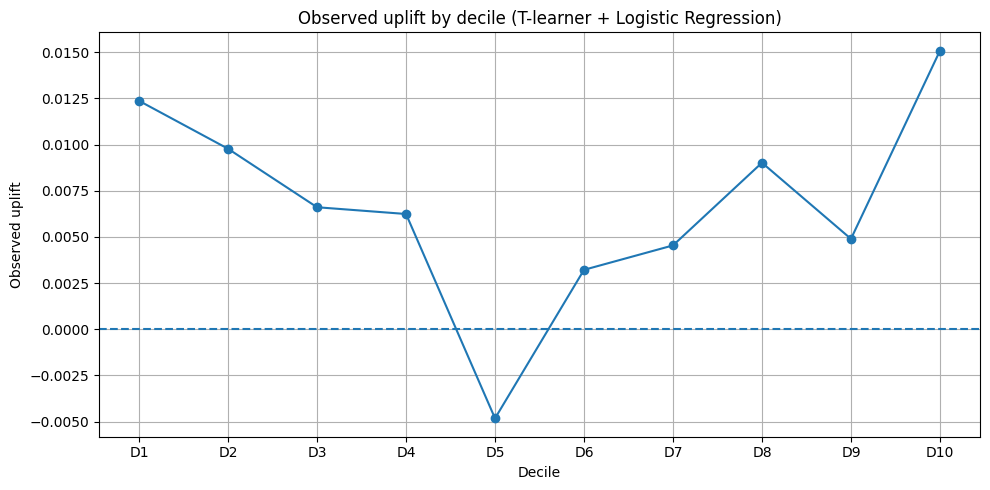

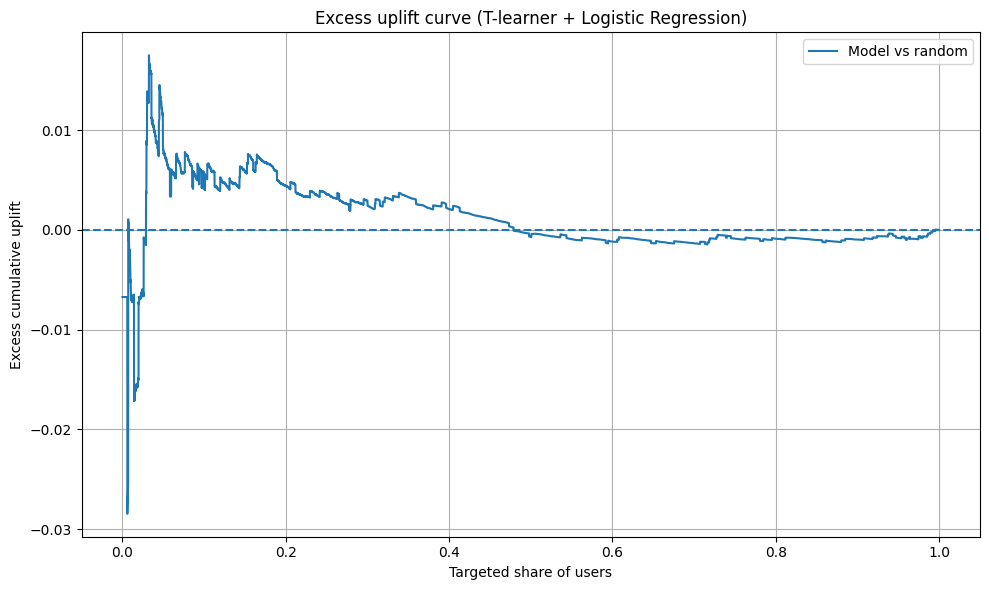

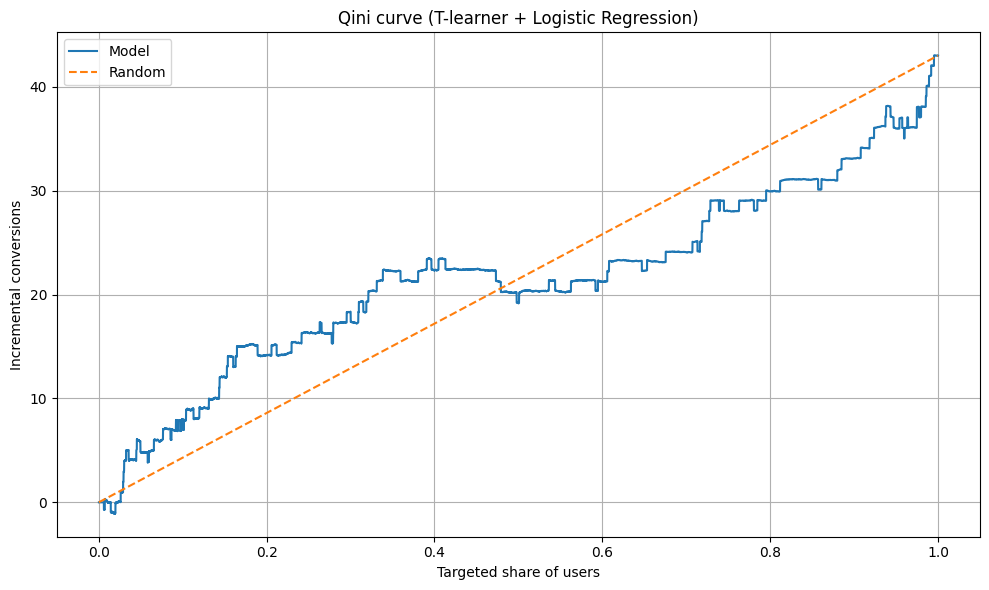

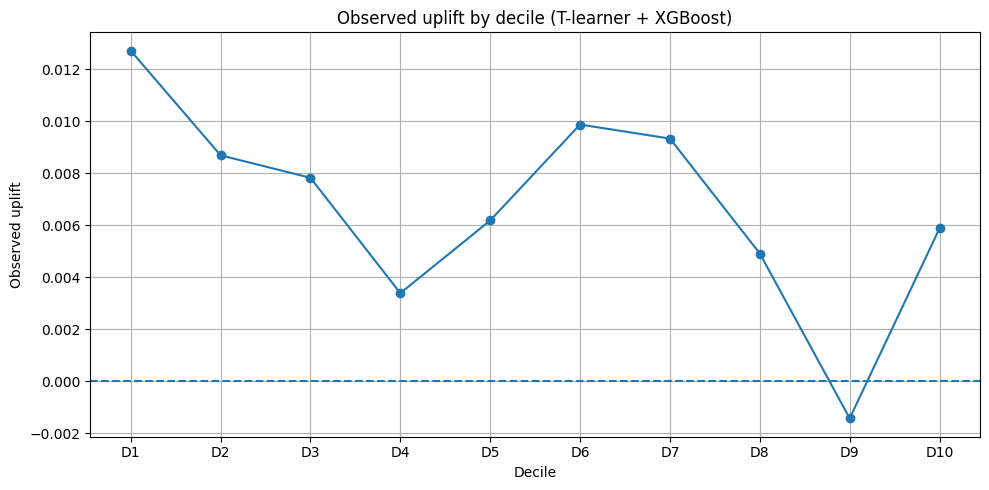

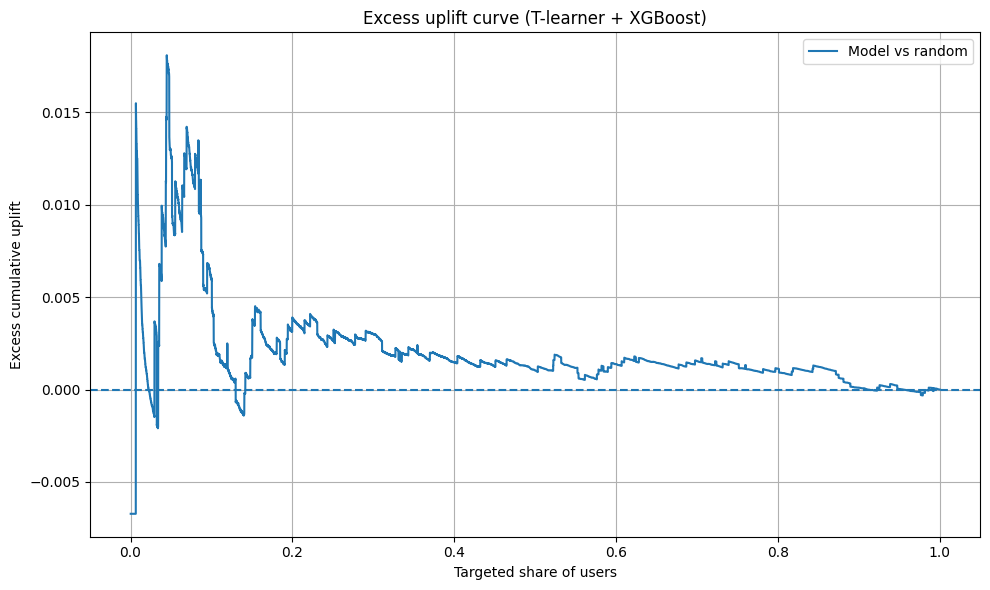

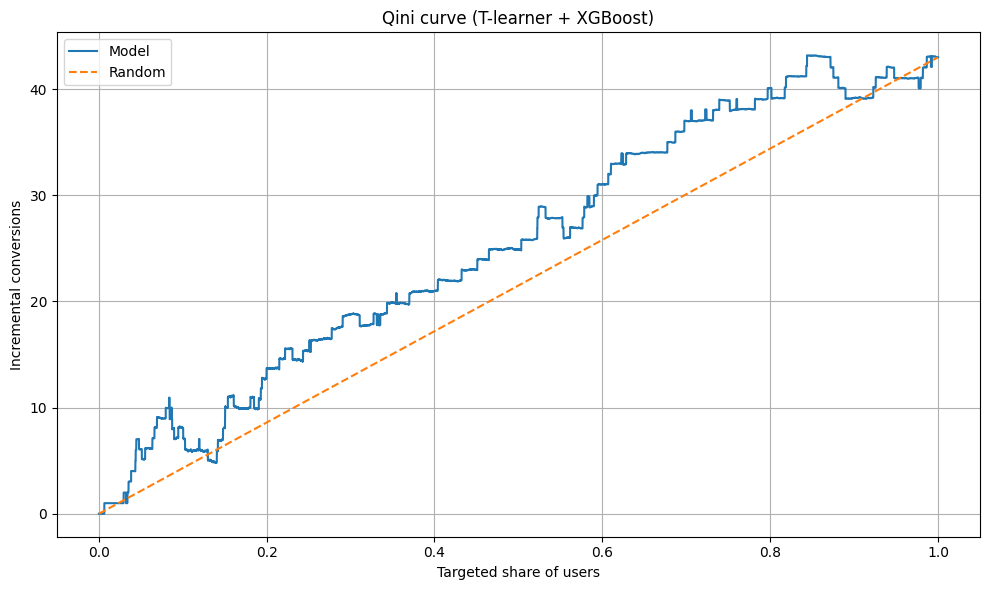

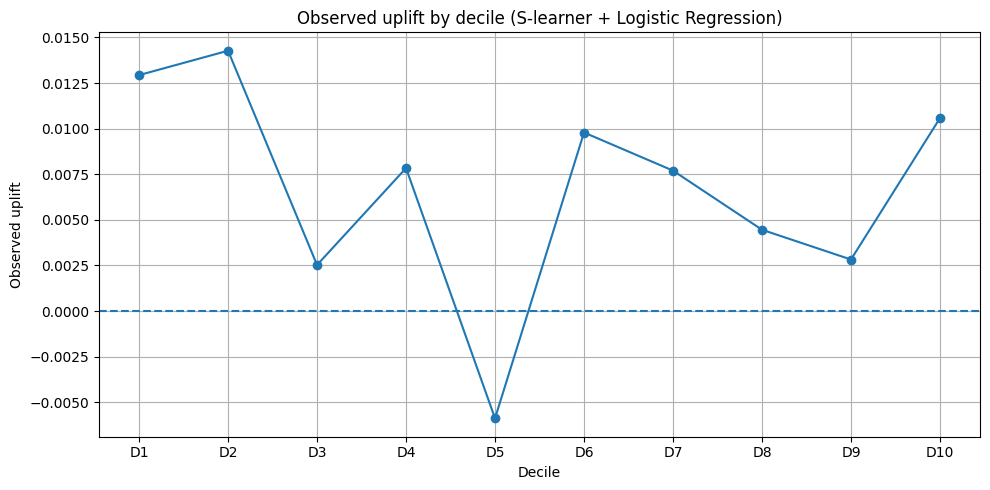

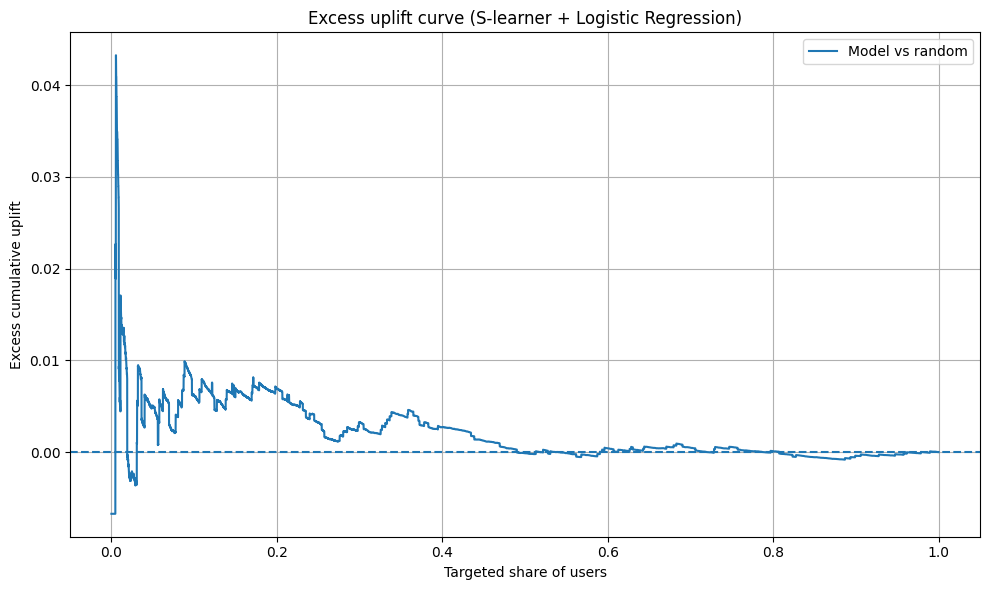

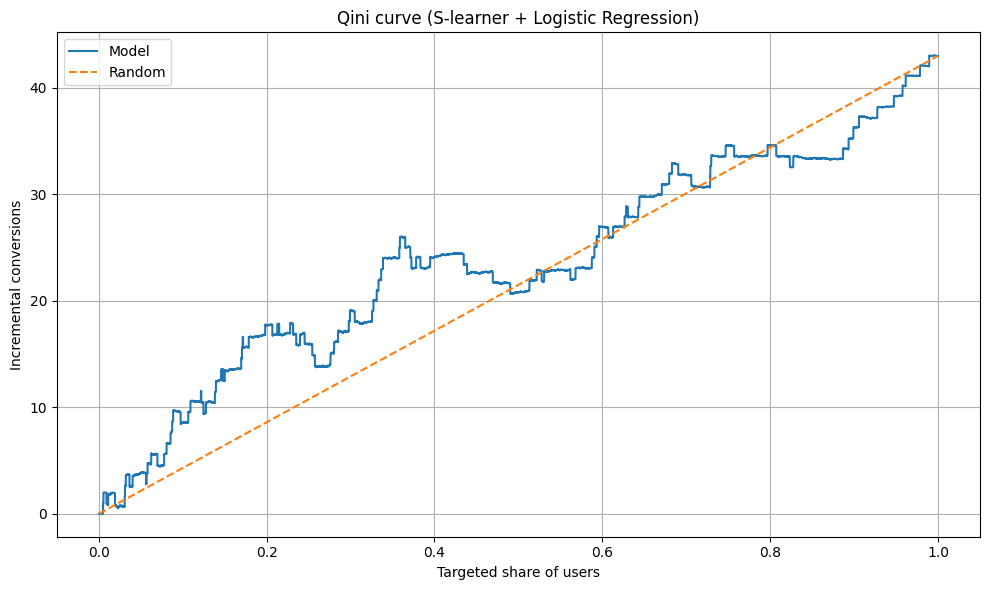

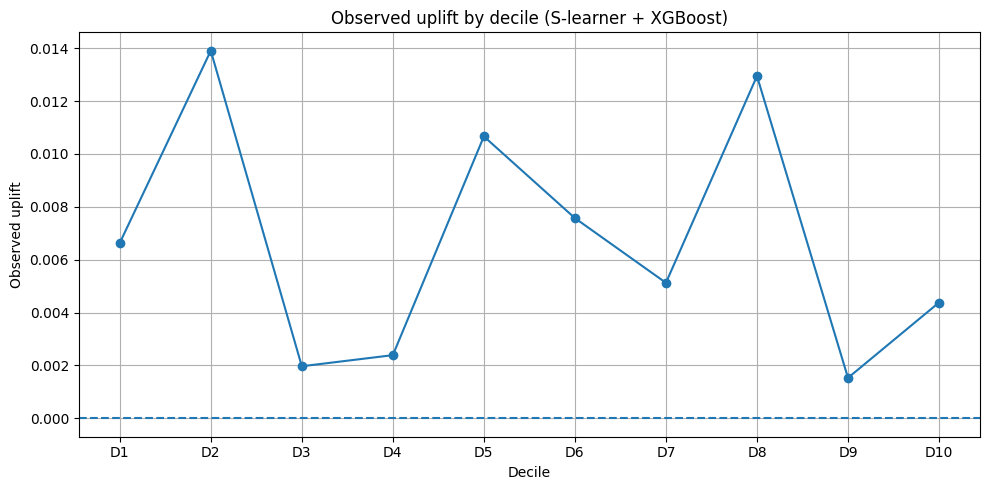

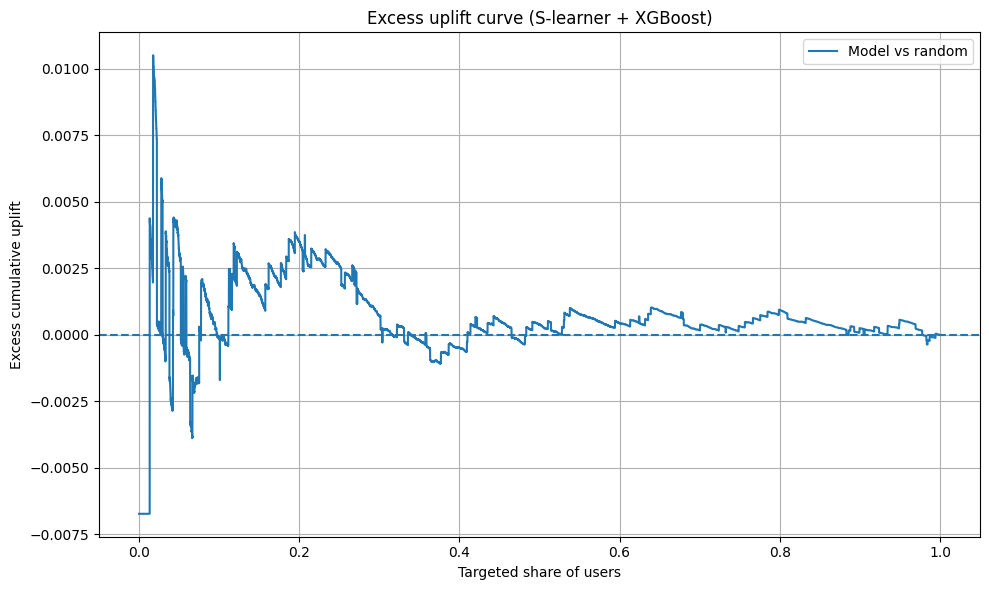

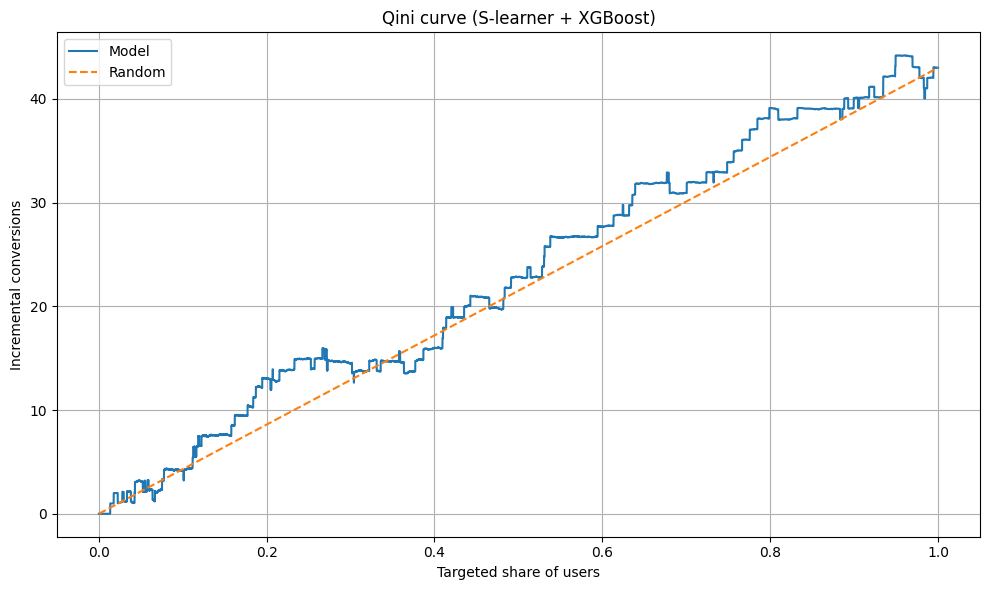

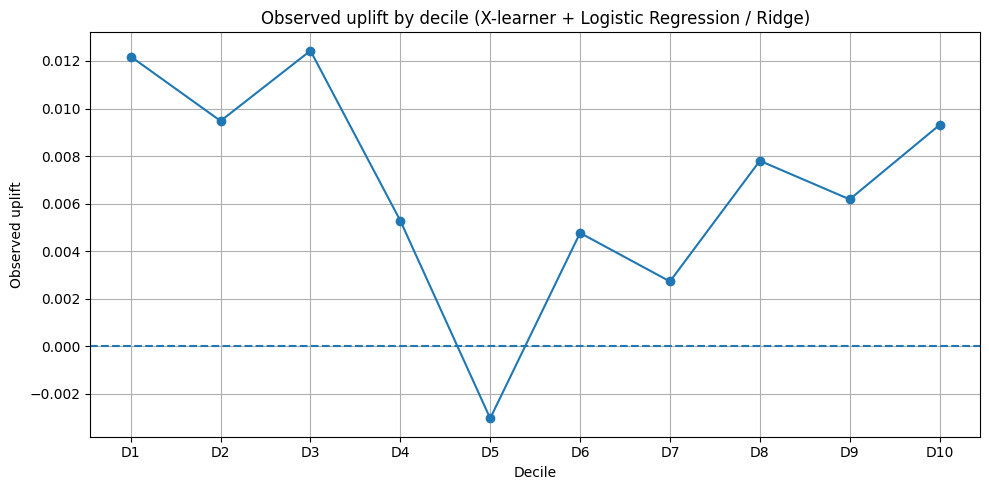

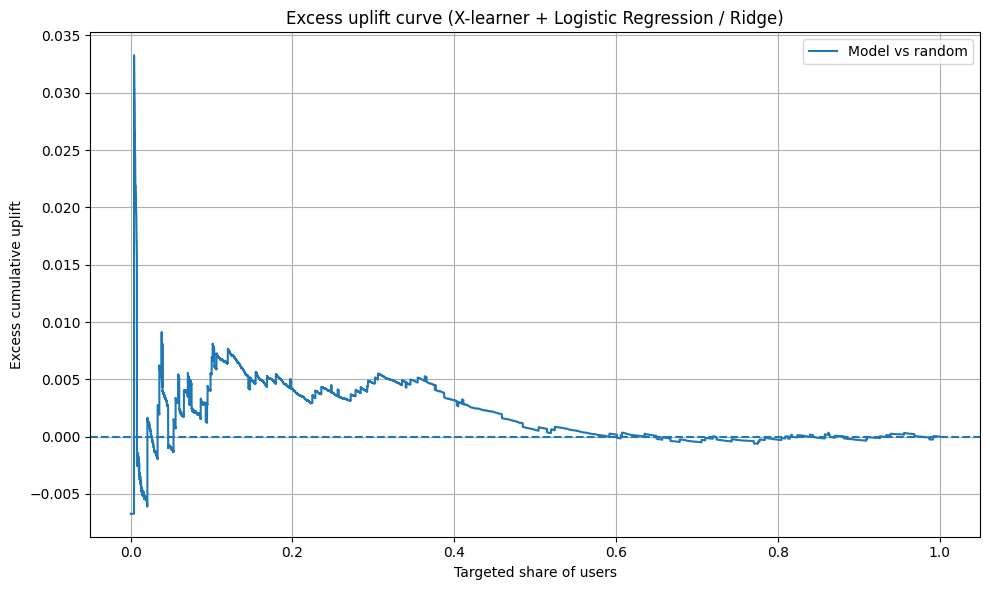

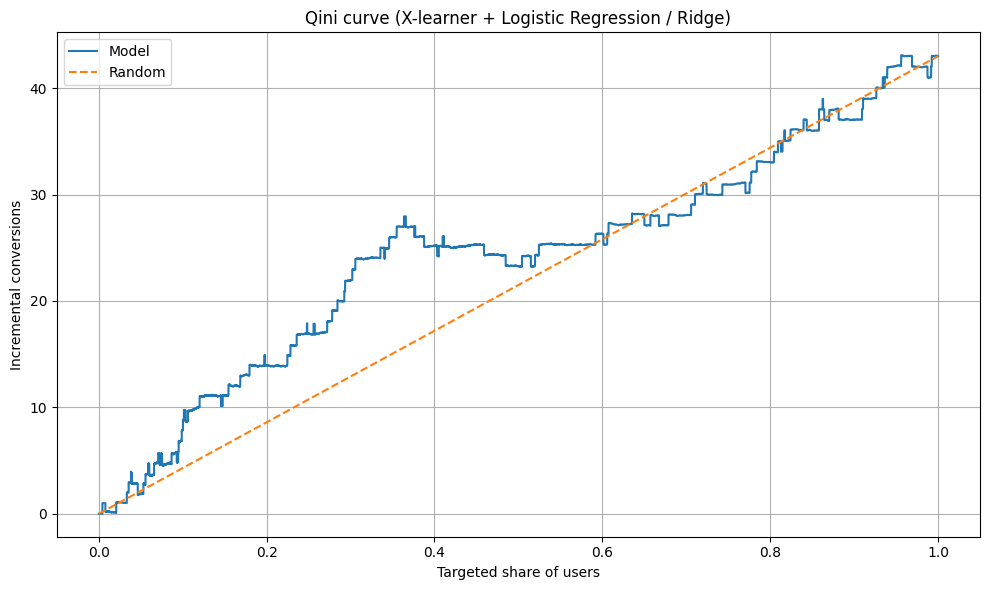

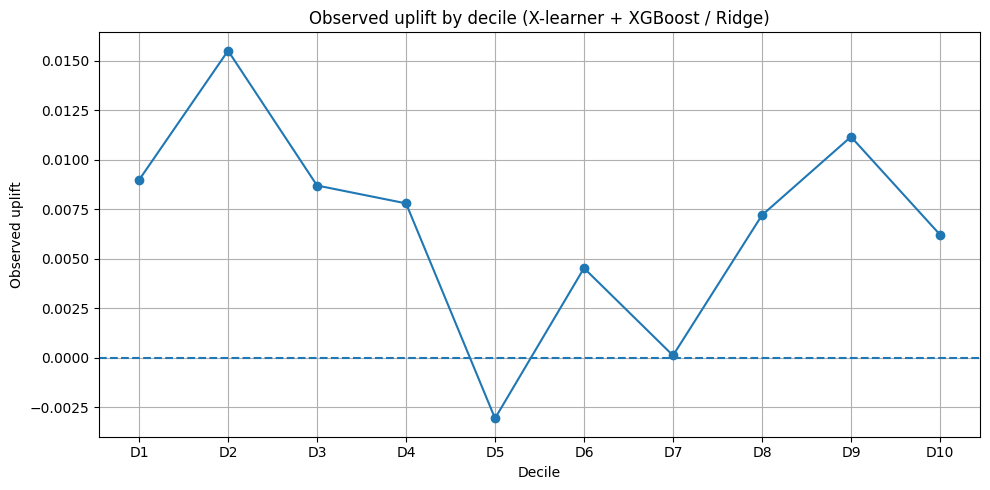

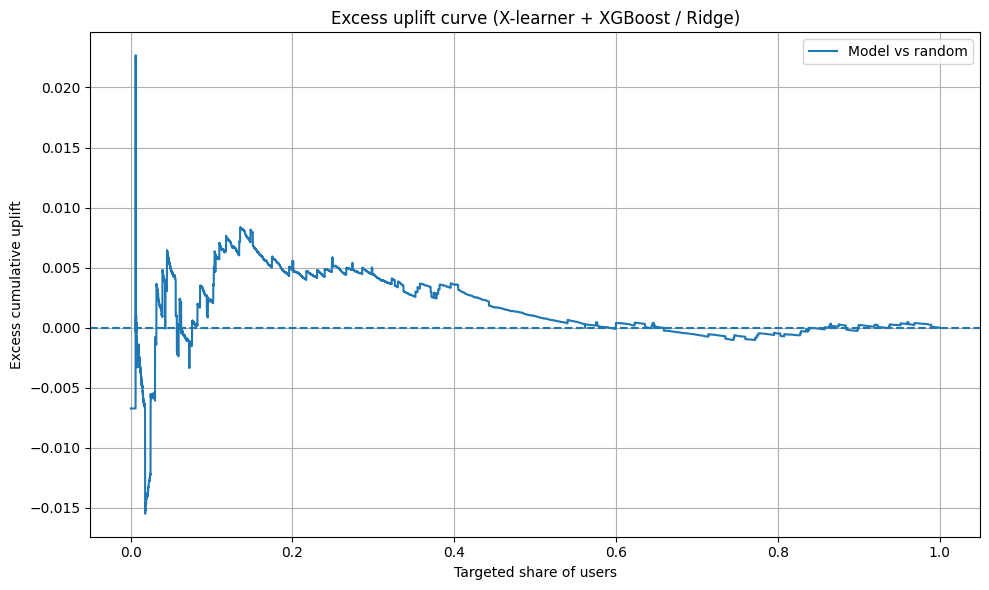

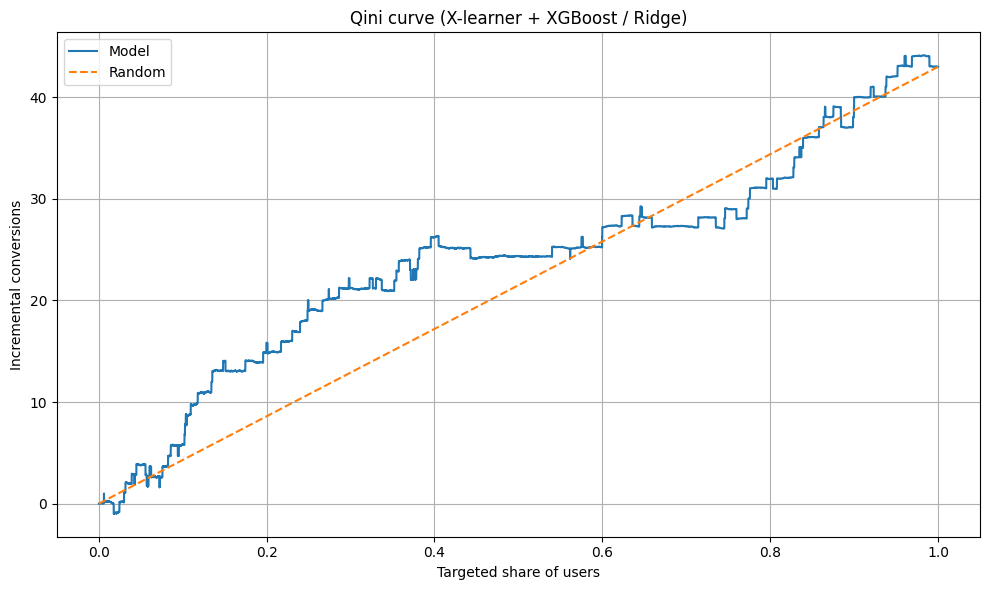

In [18]:
# Plots for all uplift models

models_to_plot = [
    "T-learner + Logistic Regression",
    "T-learner + XGBoost",
    "S-learner + Logistic Regression",
    "S-learner + XGBoost",
    "X-learner + Logistic Regression / Ridge",
    "X-learner + XGBoost / Ridge",
]

for model_name in models_to_plot:
    _ = evaluate_uplift_model(
        uplift_results=single_split_results[model_name]["fit"]["uplift_results"],
        model_name=model_name,
        top_share=0.2,
        n_bins=10,
        plot=True
    )

- The plots confirm that T-learner + XGBoost has the most convincing uplift pattern among the selected models: its Qini curve stays above random for most of the range, and the excess uplift curve remains mostly positive.
- T-learner + Logistic Regression looks the least reliable: its decile uplift is unstable, the excess uplift fades toward zero, and the Qini curve stays close to the random baseline.
- The remaining models show some positive uplift signal relative to random targeting, but their performance is less consistent and their ranking quality is not strong enough to support a clear advantage over the leading model.

<a id="final-conclusions"></a>
## Final conclusions

- The `Mens E-Mail` campaign produced a statistically significant and practically meaningful increase in conversion relative to the control group, with an absolute uplift of 0.68 percentage points.
- CUPED was implemented correctly, but it did not provide a meaningful practical benefit for spend because the pre-treatment covariate used for adjustment had almost no relationship with post-treatment spend.
- The uplift analysis suggests that treatment effects are heterogeneous across users. In the evaluated comparison, T-learner + XGBoost delivered the strongest ranking performance, while the remaining models showed weaker or less consistent separation from random targeting.
- Overall, the project supports two main conclusions: the campaign is effective on average, and targeted treatment allocation has the potential to improve efficiency beyond a uniform treatment policy.